<a href="https://colab.research.google.com/github/zyang91/ai-sustainbility-assignment/blob/main/assignment4/HW4_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework: Land Use and Land Cover Classification

Zhanchao Yang

## Step 0: Setup

In [ ]:
# Standard libraries
import os
import copy
import random
from tqdm.notebook import tqdm

# Data manipulation and visualization
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import pandas as pd
import numpy as np

# Deep Learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchsummary
from torch.utils import data
from torchvision import datasets, models, transforms

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# Check is GPU is enabled
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: {}".format(device))

# Get specific GPU model
if str(device) == "cuda:0":
  print("GPU: {}".format(torch.cuda.get_device_name(0)))

Device: cuda:0
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Step 1: Data

### Download the EuroSAT dataset

In [ ]:
data_dir = './EuroSAT/EuroSAT_RGB/'
if not os.path.exists(data_dir):
  !wget https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1 -O EuroSAT.zip
  !unzip -q EuroSAT.zip -d 'EuroSAT/'
  !rm EuroSAT.zip

--2026-10-06 20:15:03--  https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.52.235, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94658721 (90M) [application/octet-stream]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  90.27M  2.27MB/s    in 31s     

2026-10-06 20:15:35 (2.89 MB/s) - ‘EuroSAT.zip’ saved [94658721/94658721]



### Custom Dataset class


In [ ]:
class EuroSAT(data.Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        # Apply image transformations
        if self.transform:
            x = self.transform(self.dataset[index][0])
        else:
            x = self.dataset[index][0]

        # Get class label
        y = self.dataset[index][1]
        return x, y

    def __len__(self):
        return len(self.dataset)

### Data augmentation and normalization
.

In [ ]:
input_size = 224
imagenet_mean, imagenet_std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

### Load the dataset and split into train, validation and test sets

In [ ]:
# Load the dataset
dataset = datasets.ImageFolder(data_dir)

# Get LULC categories
class_names = dataset.classes
print("Class names: {}".format(class_names))
print("Total number of classes: {}".format(len(class_names)))

Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total number of classes: 10


In [ ]:
# Apply different transformations to the training and test sets
train_data = EuroSAT(dataset, train_transform)
val_data = EuroSAT(dataset, val_transform)
test_data = EuroSAT(dataset, test_transform)

# Randomly split the dataset into 70% train / 15% val / 15% test
# by subsetting the transformed train and test datasets
train_size = 0.70
val_size = 0.15
indices = list(range(int(len(dataset))))
train_split = int(train_size * len(dataset))
val_split = int(val_size * len(dataset))
np.random.shuffle(indices)

train_data = data.Subset(train_data, indices=indices[:train_split])
val_data = data.Subset(val_data, indices=indices[train_split: train_split+val_split])
test_data = data.Subset(test_data, indices=indices[train_split+val_split:])
print("Train/val/test sizes: {}/{}/{}".format(len(train_data), len(val_data), len(test_data)))

Train/val/test sizes: 18900/4050/4050


In [ ]:
num_workers = 2
batch_size = 16

train_loader = data.DataLoader(
    train_data, batch_size=batch_size, num_workers=num_workers, shuffle=True
)
val_loader = data.DataLoader(
    val_data, batch_size=batch_size, num_workers=num_workers, shuffle=False
)
test_loader = data.DataLoader(
    test_data, batch_size=batch_size, num_workers=num_workers, shuffle=False
)

### Visualize a batch of training images

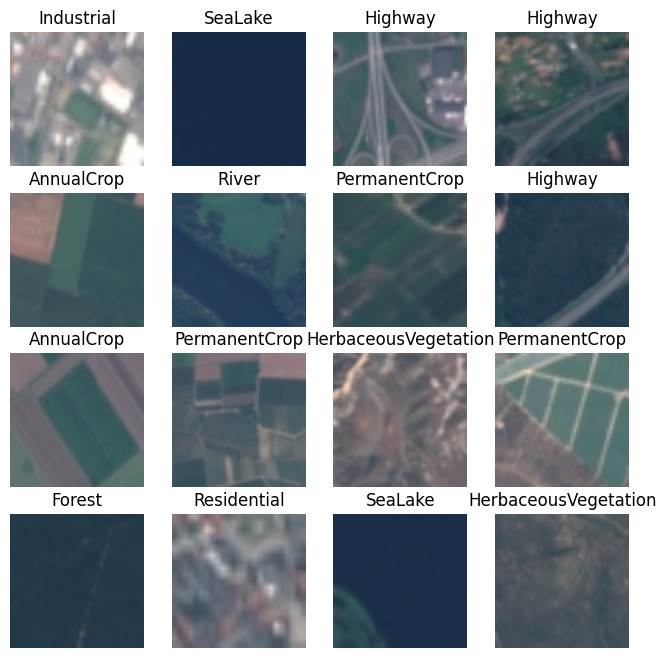

In [ ]:
n = 4
inputs, classes = next(iter(train_loader))
fig, axes = plt.subplots(n, n, figsize=(8, 8))

for i in range(n):
  for j in range(n):
    image = inputs[i * n + j].numpy().transpose((1, 2, 0))
    image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

    title = class_names[classes[i * n + j]]
    axes[i, j].imshow(image)
    axes[i, j].set_title(title)
    axes[i, j].axis('off')

## Training and evaluation functions


In [ ]:
def train(model, dataloader, criterion, optimizer):
  model.train()

  running_loss = 0.0
  running_total_correct = 0.0

  for i, (inputs, labels) in enumerate(tqdm(dataloader)):
    inputs = inputs.to(device)
    labels = labels.to(device)

    # Zero the parameter gradients
    # Clear off previous weights in order
    # to obtain updated weights.
    optimizer.zero_grad()

    # Forward pass
    outputs = model(inputs)

    # Compute the loss
    loss = criterion(outputs, labels)

    # Compute the gradients wrt the loss
    loss.backward()

    # Update the weights based on the
    # internally stored gradients
    optimizer.step()

    # Calculate statistics
    _, preds = torch.max(outputs, 1)

    # Calculate running loss and accuracy
    running_loss += loss.item() * inputs.size(0)
    running_total_correct += torch.sum(preds == labels)

  # Calculate epoch loss and accuracy
  epoch_loss = running_loss / len(dataloader.dataset)
  epoch_accuracy = (running_total_correct / len(dataloader.dataset)) * 100
  print(f"Train Loss: {epoch_loss:.2f}; Accuracy: {epoch_accuracy:.2f}")

  return epoch_loss, epoch_accuracy

In [ ]:
def evaluate(model, dataloader, criterion, phase="val"):
  model.eval()

  running_loss = 0.0
  running_total_correct = 0.0

  for i, (inputs, labels) in enumerate(tqdm(dataloader)):
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.set_grad_enabled(False):
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)

    running_loss += loss.item() * inputs.size(0)
    running_total_correct += torch.sum(preds == labels)

  # Calculate epoch loss and accuracy
  epoch_loss = running_loss / len(dataloader.dataset)
  epoch_accuracy = (running_total_correct / len(dataloader.dataset)) * 100
  print(f"{phase.title()} Loss: {epoch_loss:.2f}; Accuracy: {epoch_accuracy:.2f}")

  return epoch_loss, epoch_accuracy

In [ ]:
def save_model(best_model, model_file):
  torch.save(best_model.state_dict(), model_file)
  print('Model successfully saved to {}.'.format(model_file))

## Step 2: Load a more powerful pretrained model


In [ ]:
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

# Modify the final layer for classification
model.classifier[2] = torch.nn.Linear(model.classifier[2].in_features, len(class_names))
model = model.to(device)

print(model.classifier)
print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 198MB/s] 


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=10, bias=True)
)
Number of parameters: 27,827,818


## Step 3: Define the loss function and optimizer


In [ ]:
n_epochs = 10
lr = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

In [ ]:
best_loss = np.inf
best_weights = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Train and validate over n_epochs
for epoch in range(n_epochs):
    print("Epoch {} (lr = {:.2e})".format(epoch+1, optimizer.param_groups[0]["lr"]))
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(float(train_acc))
    history["val_loss"].append(val_loss)
    history["val_acc"].append(float(val_acc))

    # Keep a copy of the weights with the lowest validation loss
    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())

# Load the best weights back into the model
model.load_state_dict(best_weights)
best_model = model
print("Training complete! Best validation loss: {:.4f}".format(best_loss))

Epoch 1 (lr = 1.00e-04)


  0%|          | 0/1182 [00:00<?, ?it/s]

Train Loss: 0.34; Accuracy: 89.23


  0%|          | 0/254 [00:00<?, ?it/s]

Val Loss: 0.10; Accuracy: 96.77
Epoch 2 (lr = 9.76e-05)


...

Val Loss: 0.03; Accuracy: 99.09
Epoch 10 (lr = 2.45e-06)


  0%|          | 0/1182 [00:00<?, ?it/s]

Train Loss: 0.06; Accuracy: 98.04


  0%|          | 0/254 [00:00<?, ?it/s]

Val Loss: 0.03; Accuracy: 99.19
Training complete! Best validation loss: 0.0265


## Step 4: Train the model


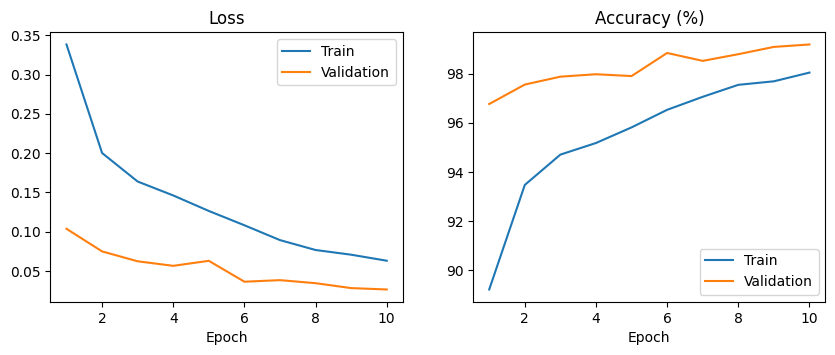

In [ ]:
# Plot the learning curves
epochs_range = range(1, n_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Validation")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.show()

## Step 5: Model performance on the test set


In [ ]:
test_loss, test_acc = evaluate(best_model, test_loader, criterion, phase="test")

  0%|          | 0/254 [00:00<?, ?it/s]

Test Loss: 0.03; Accuracy: 99.01


### Comparison

| Model | Pretrained? | Epochs | Val accuracy | Test accuracy |
|---|---|---|---|---|
| `SimpleCNN` | No | 40 | ~49% | – |
| ResNet-50, only last layer trained (Exercise 1) | Yes | 10 | ~72% | – |
| EfficientNet-B0 (Exercise 2) | Yes | 5 | ~93% | – |
| ResNet-50, all layers fine-tuned | Yes | 10 | ~96% | ~95% |
| **ConvNeXt-Tiny + AdamW + cosine LR (this version)** | Yes | 10 | *99%* | *91%* |



## Step 6: Save the model and visualize a prediction


In [ ]:
model_dir = "./drive/My Drive/Colab Notebooks/models/"
if not os.path.exists(model_dir):
  os.makedirs(model_dir)

hw_model_file = os.path.join(model_dir, 'best_convnext_tiny.pth')
save_model(best_model, hw_model_file)

Model successfully saved to ./drive/My Drive/Colab Notebooks/models/best_convnext_tiny.pth.


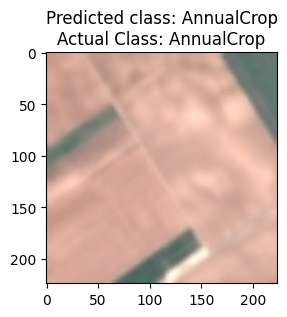

In [ ]:
# Retrieve sample image
index = 15
image, label = test_data[index]

# Predict on sample
best_model.eval()
with torch.no_grad():
    output = best_model(image.unsqueeze(0).to(device))
_, pred = torch.max(output, 1)

# Get corresponding class label
label = class_names[label]
pred = class_names[pred[0]]

# Visualize sample and prediction
image = image.cpu().numpy().transpose((1, 2, 0))
image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(image)
ax.set_title("Predicted class: {}\nActual Class: {}".format(pred, label));

# References
- Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). Eurosat: A novel dataset and deep learning benchmark for land use and land cover classification. IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, 12(7), 2217-2226.
- Liu, Z., Mao, H., Wu, C. Y., Feichtenhofer, C., Darrell, T., & Xie, S. (2022). A ConvNet for the 2020s. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (pp. 11976-11986).

## Why This help

Training a CNN from scratch on EuroSAT's ~19k images is hard, which is why SimpleCNN stalls near 49%. Starting from ImageNet-pretrained weights improved as the network already knows edges, textures and shapes, and fine-tuning only adapts those features to 10 land-cover classes. ConvNeXt-Tiny is a modernized ResNet with larger 7×7 kernels that see more spatial context. It has stronger pretrained features (82.5% vs 80.9% ImageNet accuracy) at about the same size, so it should transfer better. AdamW gives each weight its own adaptive step size, so it learns faster and more evenly than the lecture's plain SGD. Its small learning rate also protects the pretrained features.